In [1]:
# 07_experiments.ipynb - Експерименти з різними архітектурами

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import json
from datetime import datetime

from src.config import DATA_DIR, MODELS_DIR, FIGURES_DIR, RANDOM_SEED, MAX_SEQUENCE_LENGTH

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'experiments').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'experiments').mkdir(parents=True, exist_ok=True)

# Встановлюємо seed
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("="*60)
print("ЕКСПЕРИМЕНТИ З РІЗНИМИ АРХІТЕКТУРАМИ")
print("="*60)
print(f"TensorFlow версія: {tf.__version__}")
print(f"Час запуску: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

ЕКСПЕРИМЕНТИ З РІЗНИМИ АРХІТЕКТУРАМИ
TensorFlow версія: 2.21.0
Час запуску: 2026-03-27 19:51:31


In [2]:
print("Завантаження даних...")

# Завантажуємо дані
X_train = np.load(DATA_DIR / 'X_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')

y_train = np.load(DATA_DIR / 'y_train.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

# Завантажуємо інформацію
with open(DATA_DIR / 'preprocessing_info.json', 'r') as f:
    preprocessing_info = json.load(f)

vocab_size = preprocessing_info['vocab_size']

print(f"\n✅ Дані завантажено:")
print(f"  Train: {X_train.shape[0]:,} сесій")
print(f"  Val:   {X_val.shape[0]:,} сесій")
print(f"  Test:  {X_test.shape[0]:,} сесій")
print(f"  vocab_size: {vocab_size:,}")

# Для швидкості експериментів беремо 20% даних
sample_size = int(len(X_train) * 0.2)
X_train_sample = X_train[:sample_size]
y_train_sample = y_train[:sample_size]

print(f"\n⚠️ Для прискорення експериментів використовуємо {sample_size:,} сесій (20%)")

Завантаження даних...

✅ Дані завантажено:
  Train: 6,474,810 сесій
  Val:   1,387,459 сесій
  Test:  1,387,460 сесій
  vocab_size: 52,740

⚠️ Для прискорення експериментів використовуємо 1,294,962 сесій (20%)


In [6]:
print("="*60)
print("НАЛАШТУВАННЯ ФУНКЦІЇ ТРЕНУВАННЯ")
print("="*60)

def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, epochs=10):
    """
    Тренує та оцінює модель
    """
    print(f"\n{'='*60}")
    print(f"ТРЕНУВАННЯ: {model_name}")
    print('='*60)
    
    # Компіляція
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, verbose=0, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ]
    
    # Тренування
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=128,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0  # тихий режим для чистоти виводу
    )
    
    # Оцінка на тесті
    y_pred_proba = model.predict(X_test, batch_size=128, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Найкращі значення
    best_val_auc = max(history.history['val_auc'])
    best_epoch = np.argmax(history.history['val_auc']) + 1
    
    print(f"\n📊 РЕЗУЛЬТАТИ {model_name}:")
    print(f"  Краща епоха: {best_epoch}")
    print(f"  Val AUC: {best_val_auc:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print(f"  Test ROC-AUC:  {test_auc:.4f}")
    
    return {
        'name': model_name,
        'best_epoch': best_epoch,
        'best_val_auc': best_val_auc,
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'history': history
    }

НАЛАШТУВАННЯ ФУНКЦІЇ ТРЕНУВАННЯ


In [7]:
print("="*60)
print("ЕКСПЕРИМЕНТ 1: БАЗОВА LSTM (контроль)")
print("="*60)

def create_baseline_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

baseline_lstm = create_baseline_lstm()
result_baseline = train_and_evaluate(
    baseline_lstm, "LSTM (Baseline)",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test, epochs=10
)

ЕКСПЕРИМЕНТ 1: БАЗОВА LSTM (контроль)

ТРЕНУВАННЯ: LSTM (Baseline)

📊 РЕЗУЛЬТАТИ LSTM (Baseline):
  Краща епоха: 1
  Val AUC: 0.7816
  Test Accuracy: 0.9449
  Test F1-Score: 0.0031
  Test ROC-AUC:  0.7829


In [8]:
print("="*60)
print("ЕКСПЕРИМЕНТ 2: GRU (замість LSTM)")
print("="*60)

def create_gru_model():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        GRU(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

gru_model = create_gru_model()
result_gru = train_and_evaluate(
    gru_model, "GRU",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test, epochs=10
)

ЕКСПЕРИМЕНТ 2: GRU (замість LSTM)

ТРЕНУВАННЯ: GRU

📊 РЕЗУЛЬТАТИ GRU:
  Краща епоха: 1
  Val AUC: 0.7841
  Test Accuracy: 0.9449
  Test F1-Score: 0.0000
  Test ROC-AUC:  0.7852


In [9]:
print("="*60)
print("ЕКСПЕРИМЕНТ 3: BIDIRECTIONAL LSTM")
print("="*60)

def create_bidirectional_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

bidirectional_model = create_bidirectional_lstm()
result_bidirectional = train_and_evaluate(
    bidirectional_model, "Bidirectional LSTM",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test, epochs=10
)

ЕКСПЕРИМЕНТ 3: BIDIRECTIONAL LSTM

ТРЕНУВАННЯ: Bidirectional LSTM

📊 РЕЗУЛЬТАТИ Bidirectional LSTM:
  Краща епоха: 1
  Val AUC: 0.7829
  Test Accuracy: 0.9449
  Test F1-Score: 0.0021
  Test ROC-AUC:  0.7842


In [10]:
print("="*60)
print("ЕКСПЕРИМЕНТ 4: ДВОШАРОВИЙ LSTM")
print("="*60)

def create_stacked_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),
        LSTM(32, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

stacked_model = create_stacked_lstm()
result_stacked = train_and_evaluate(
    stacked_model, "Stacked LSTM (2 layers)",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test, epochs=10
)

ЕКСПЕРИМЕНТ 4: ДВОШАРОВИЙ LSTM

ТРЕНУВАННЯ: Stacked LSTM (2 layers)

📊 РЕЗУЛЬТАТИ Stacked LSTM (2 layers):
  Краща епоха: 1
  Val AUC: 0.7828
  Test Accuracy: 0.9449
  Test F1-Score: 0.0000
  Test ROC-AUC:  0.7837


ПОРІВНЯННЯ РЕЗУЛЬТАТІВ ЕКСПЕРИМЕНТІВ

📊 ПОРІВНЯЛЬНА ТАБЛИЦЯ:


,Model,Val AUC,Test Accuracy,Test F1,Test ROC-AUC,Best Epoch
0,LSTM (Baseline),0.7816,0.9449,0.0031,0.7829,1
1,GRU,0.7841,0.9449,0.0000,0.7852,1
2,Bidirectional LSTM,0.7829,0.9449,0.0021,0.7842,1
3,Stacked LSTM (2 layers),0.7828,0.9449,0.0000,0.7837,1


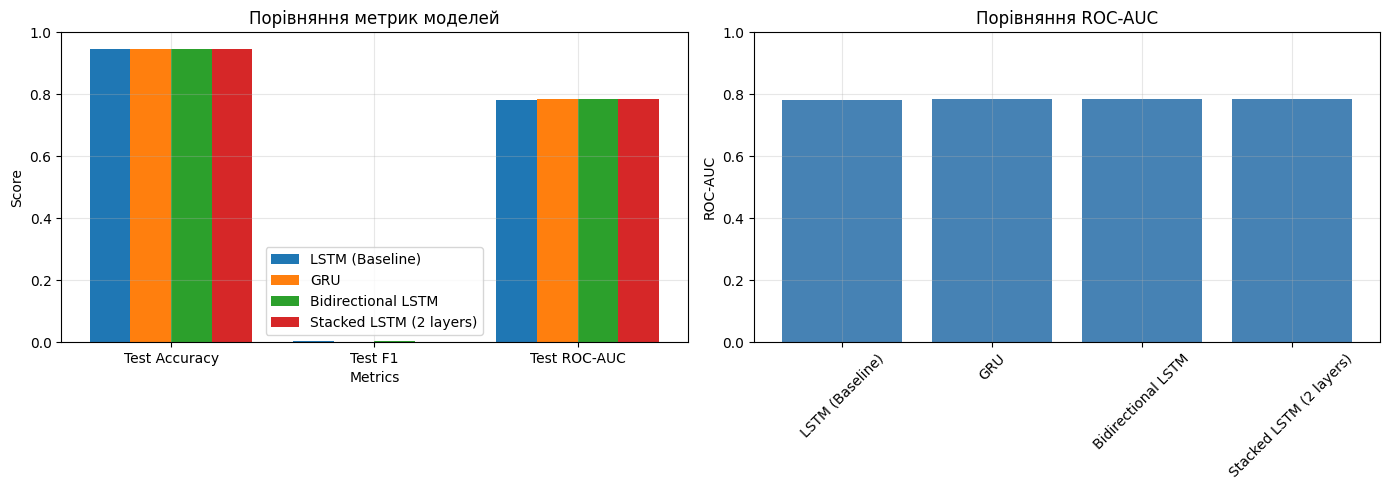

In [11]:
print("="*60)
print("ПОРІВНЯННЯ РЕЗУЛЬТАТІВ ЕКСПЕРИМЕНТІВ")
print("="*60)

# Збираємо всі результати
results = [result_baseline, result_gru, result_bidirectional, result_stacked]

# Створюємо DataFrame для порівняння
comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Val AUC': r['best_val_auc'],
        'Test Accuracy': r['test_accuracy'],
        'Test F1': r['test_f1'],
        'Test ROC-AUC': r['test_auc'],
        'Best Epoch': r['best_epoch']
    }
    for r in results
])

print("\n📊 ПОРІВНЯЛЬНА ТАБЛИЦЯ:")
display(comparison_df.round(4))

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot метрик
metrics = ['Test Accuracy', 'Test F1', 'Test ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, row in comparison_df.iterrows():
    values = [row['Test Accuracy'], row['Test F1'], row['Test ROC-AUC']]
    axes[0].bar(x + i*width, values, width, label=row['Model'])

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Порівняння метрик моделей')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Val AUC порівняння
axes[1].bar(comparison_df['Model'], comparison_df['Test ROC-AUC'], color='steelblue')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Порівняння ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'experiments' / 'comparison.png', dpi=100, bbox_inches='tight')
plt.show()

АНАЛІЗ ІСТОРІЇ ТРЕНУВАННЯ


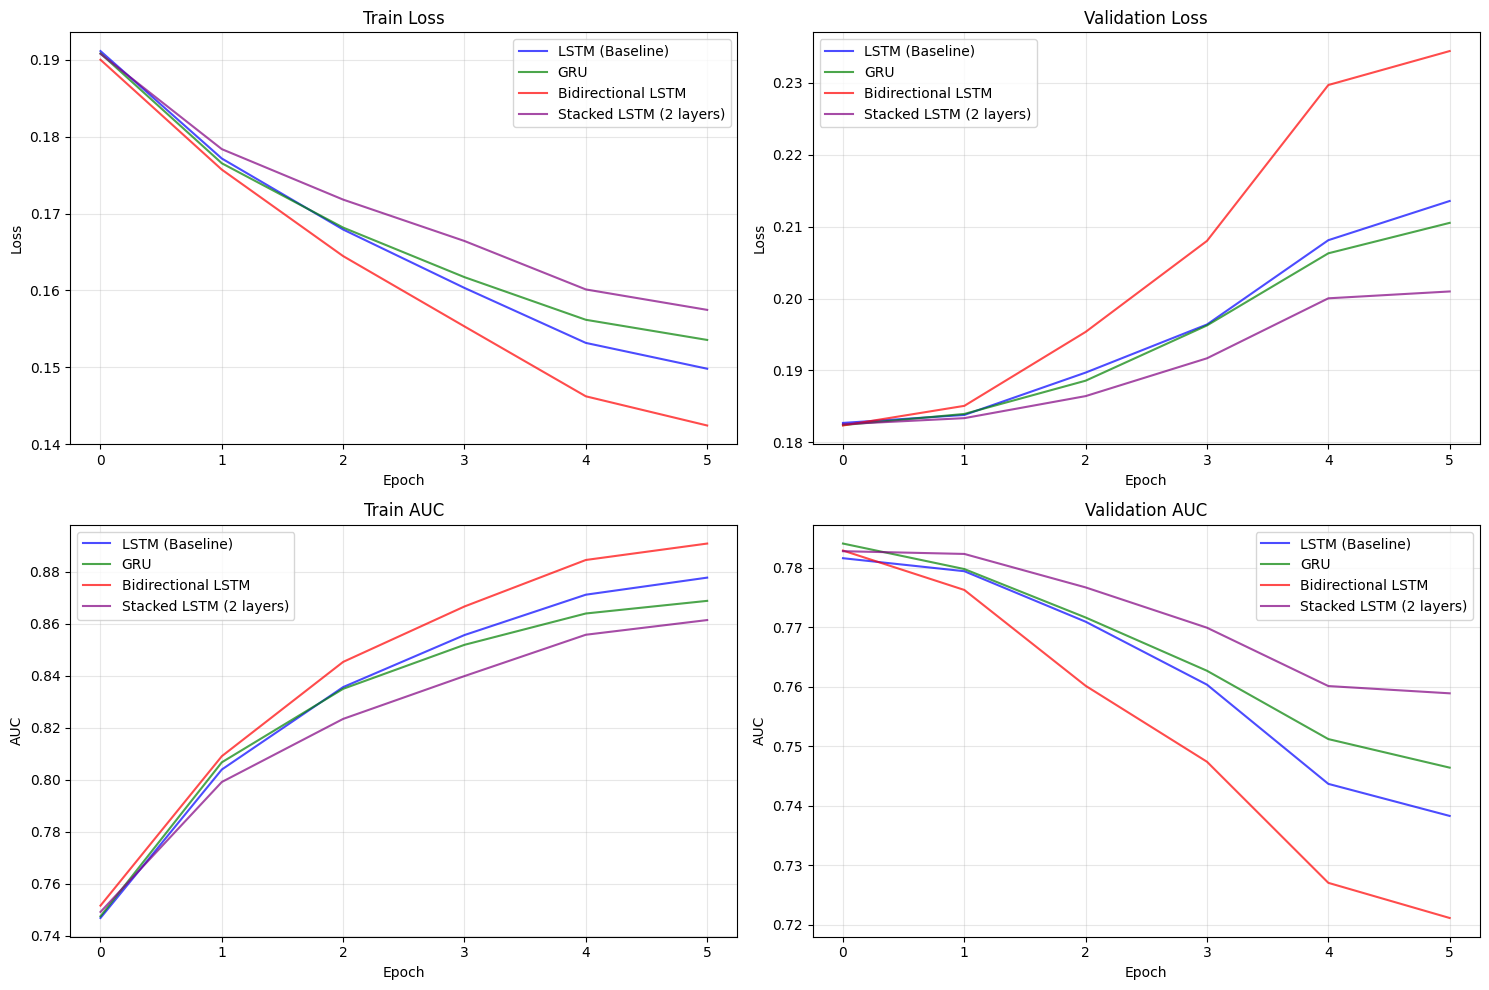

In [12]:
print("="*60)
print("АНАЛІЗ ІСТОРІЇ ТРЕНУВАННЯ")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

colors = ['blue', 'green', 'red', 'purple']

for i, result in enumerate(results):
    history = result['history']
    axes[0, 0].plot(history.history['loss'], label=result['name'], color=colors[i], alpha=0.7)
    axes[0, 1].plot(history.history['val_loss'], label=result['name'], color=colors[i], alpha=0.7)
    axes[1, 0].plot(history.history['auc'], label=result['name'], color=colors[i], alpha=0.7)
    axes[1, 1].plot(history.history['val_auc'], label=result['name'], color=colors[i], alpha=0.7)

axes[0, 0].set_title('Train Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Train AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Validation AUC')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'experiments' / 'training_history.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
print("="*60)
print("ВИБІР НАЙКРАЩОЇ МОДЕЛІ")
print("="*60)

# Знаходимо найкращу модель за ROC-AUC
best_result = max(results, key=lambda x: x['test_auc'])

print(f"\n🏆 НАЙКРАЩА МОДЕЛЬ: {best_result['name']}")
print(f"\n📊 ЇЇ МЕТРИКИ:")
print(f"  Test ROC-AUC:  {best_result['test_auc']:.4f} ({best_result['test_auc']*100:.2f}%)")
print(f"  Test F1-Score: {best_result['test_f1']:.4f} ({best_result['test_f1']*100:.2f}%)")
print(f"  Test Accuracy: {best_result['test_accuracy']:.4f} ({best_result['test_accuracy']*100:.2f}%)")
print(f"  Best Val AUC:  {best_result['best_val_auc']:.4f}")

# Порівняння з baseline LSTM
baseline_auc = results[0]['test_auc']
improvement = (best_result['test_auc'] - baseline_auc) / baseline_auc * 100

print(f"\n📈 ПОКРАЩЕННЯ ВІДНОСНО BASELINE LSTM:")
print(f"  ROC-AUC: +{improvement:.1f}%")

ВИБІР НАЙКРАЩОЇ МОДЕЛІ

🏆 НАЙКРАЩА МОДЕЛЬ: GRU

📊 ЇЇ МЕТРИКИ:
  Test ROC-AUC:  0.7852 (78.52%)
  Test F1-Score: 0.0000 (0.00%)
  Test Accuracy: 0.9449 (94.49%)
  Best Val AUC:  0.7841

📈 ПОКРАЩЕННЯ ВІДНОСНО BASELINE LSTM:
  ROC-AUC: +0.3%


In [14]:
print("="*60)
print("ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ")
print("="*60)

# Зберігаємо порівняльну таблицю
comparison_df.to_csv(MODELS_DIR / 'experiments' / 'comparison_results.csv', index=False)
print(f"✅ Порівняльна таблиця збережена")

# Зберігаємо детальні результати
experiments_results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_model': best_result['name'],
    'best_model_metrics': {
        'test_auc': float(best_result['test_auc']),
        'test_f1': float(best_result['test_f1']),
        'test_accuracy': float(best_result['test_accuracy'])
    },
    'all_models': [
        {
            'name': r['name'],
            'test_auc': float(r['test_auc']),
            'test_f1': float(r['test_f1']),
            'test_accuracy': float(r['test_accuracy']),
            'best_val_auc': float(r['best_val_auc'])
        }
        for r in results
    ]
}

with open(MODELS_DIR / 'experiments' / 'experiments_results.json', 'w', encoding='utf-8') as f:
    json.dump(experiments_results, f, indent=4, default=str)

print(f"✅ Результати експериментів збережено")

ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ
✅ Порівняльна таблиця збережена
✅ Результати експериментів збережено


In [ ]:
print("="*60)
print("ПІДСУМКОВИЙ ЗВІТ ЕКСПЕРИМЕНТІВ")
print("="*60)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТІВ                 ║
╠══════════════════════════════════════════════════════════════╣
║  ТЕСТОВІ МОДЕЛІ:                                            ║
║    • LSTM (Baseline):    AUC = {results[0]['test_auc']:.4f}                             ║
║    • GRU:                AUC = {results[1]['test_auc']:.4f}                             ║
║    • Bidirectional LSTM: AUC = {results[2]['test_auc']:.4f}                             ║
║    • Stacked LSTM:       AUC = {results[3]['test_auc']:.4f}                             ║
╠══════════════════════════════════════════════════════════════╣
║  🏆 НАЙКРАЩА МОДЕЛЬ: {best_result['name']:<35} ║
╠══════════════════════════════════════════════════════════════╣
║  ВИСНОВКИ:                                                  ║
║    ✅ Експерименти завершено                                 ║
║    ✅ Найкраща модель: {best_result['name']}                      ║
║    📈 Покращення: +{improvement:.1f}% відносно baseline                 ║
╚══════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*60)
print("✅ ЕКСПЕРИМЕНТИ ЗАВЕРШЕНО!")
print("="*60)
print("\nНаступний крок: 08_evaluation.ipynb")
print("- Підсумкова оцінка")
print("- Порівняння з baseline")
print("- Формування висновків для курсової")